In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("/home/vince/ENSTA/4A/projet/anomalib/results/mvtec_results_22_02_2026.csv")
df["model_x_category"] = df["model"] + "_" + df["category"]
df.sort_values(["model","category"], inplace=True)

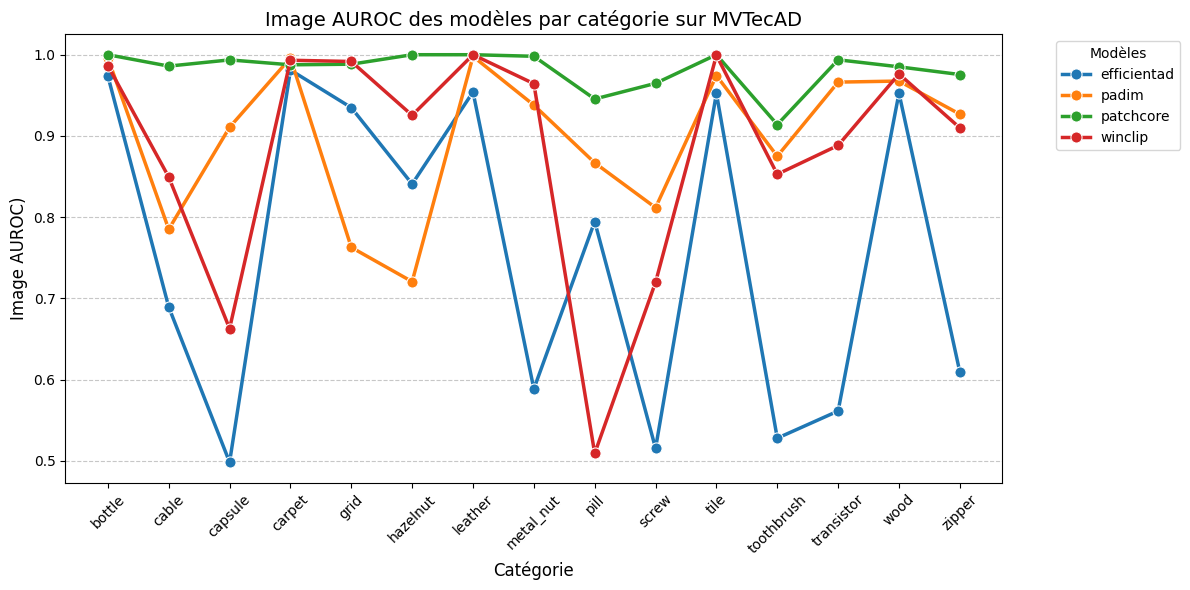

In [35]:
plt.figure(figsize=(12, 6))

# On utilise lineplot : x = catégories, y = rang, hue = modèle pour avoir une ligne par modèle
sns.lineplot(data=df, x="category", y="image_AUROC", hue="model", 
             marker="o", linewidth=2.5, markersize=8)

# 5. Esthétique
plt.title("Image AUROC des modèles par catégorie sur MVTecAD", fontsize=14)
plt.xlabel("Catégorie", fontsize=12)
plt.ylabel("Image AUROC)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Modèles", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

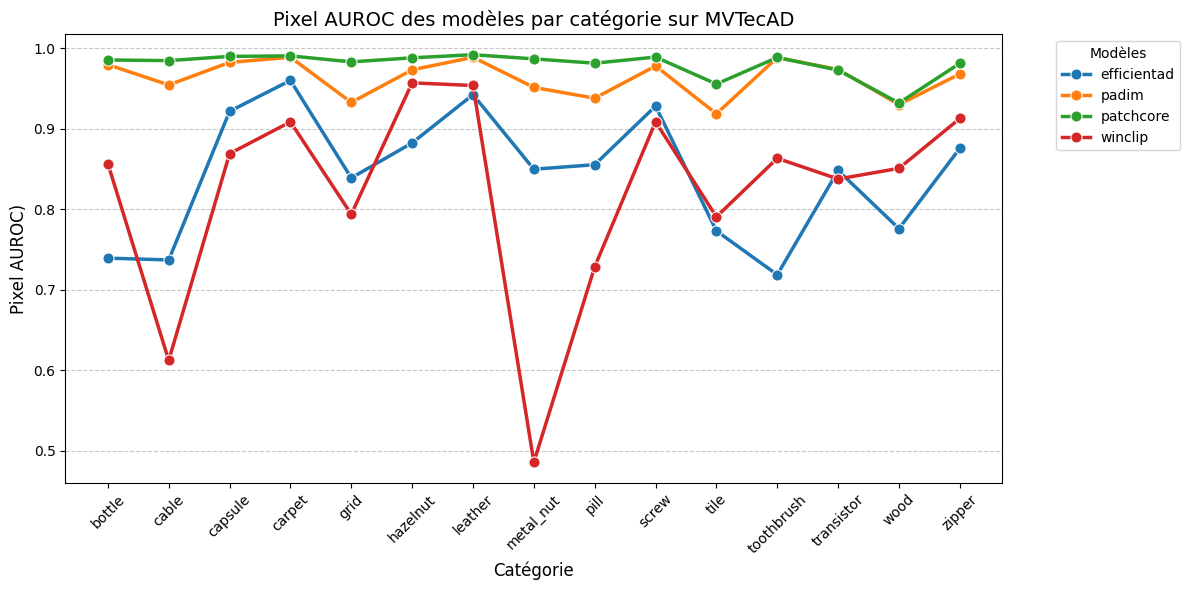

In [36]:
plt.figure(figsize=(12, 6))

# On utilise lineplot : x = catégories, y = rang, hue = modèle pour avoir une ligne par modèle
sns.lineplot(data=df, x="category", y="pixel_AUROC", hue="model", 
             marker="o", linewidth=2.5, markersize=8)

# 5. Esthétique
plt.title("Pixel AUROC des modèles par catégorie sur MVTecAD", fontsize=14)
plt.xlabel("Catégorie", fontsize=12)
plt.ylabel("Pixel AUROC)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Modèles", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Text(120.72222222222221, 0.5, 'Modèle')

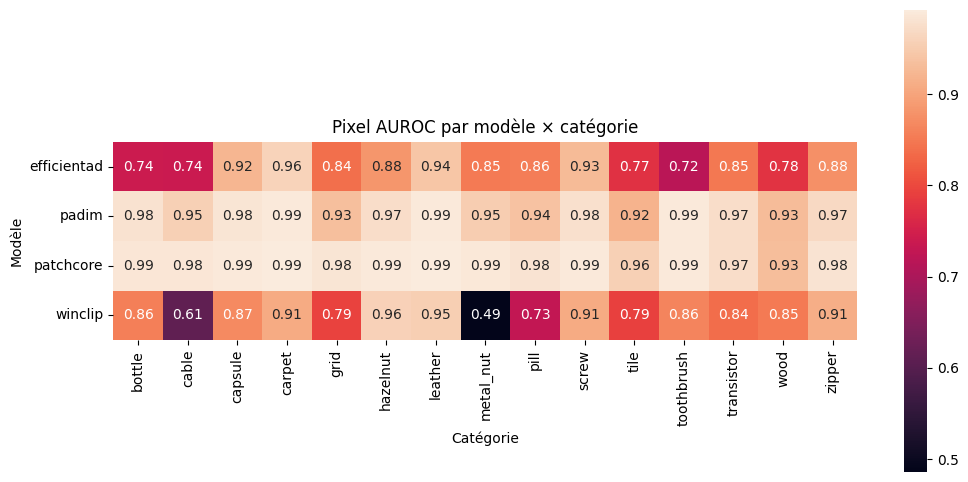

In [ ]:
df_heatmap = df.copy()
df_heatmap = df_heatmap[["pixel_AUROC","model","category"]]
df_heatmap = df_heatmap
df_heatmap = df_heatmap.pivot(columns="category", index="model", values="pixel_AUROC")
plt.figure(figsize=(12,6))
plt.title("Pixel AUROC par modèle × catégorie")
sns.heatmap(df_heatmap,annot=True,square=True)
plt.xlabel("Catégorie")
plt.ylabel("Modèle")

Text(0.5, 1.0, "Temps d'inférence moyen par modèle × catégorie")

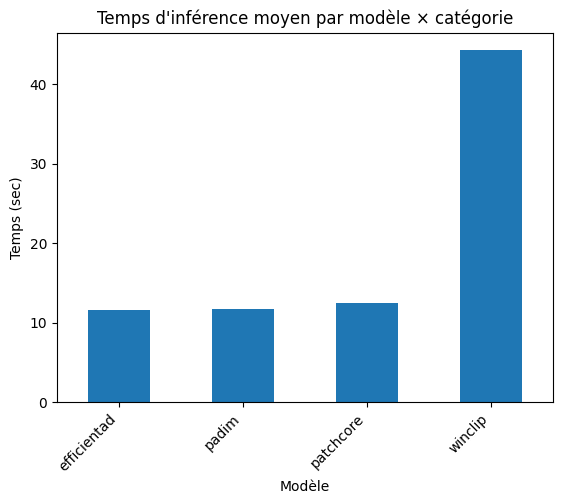

In [41]:
df_bar = df.copy()
df_bar = df_bar[["model","inference_time_sec"]]
df_bar.groupby("model").mean().plot(kind="bar", legend=False)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Modèle")
plt.ylabel("Temps (sec)")
plt.title("Temps d'inférence moyen par modèle × catégorie")


Text(0.5, 0, 'Classes (Bleu: Objets, Orange: Textures)')

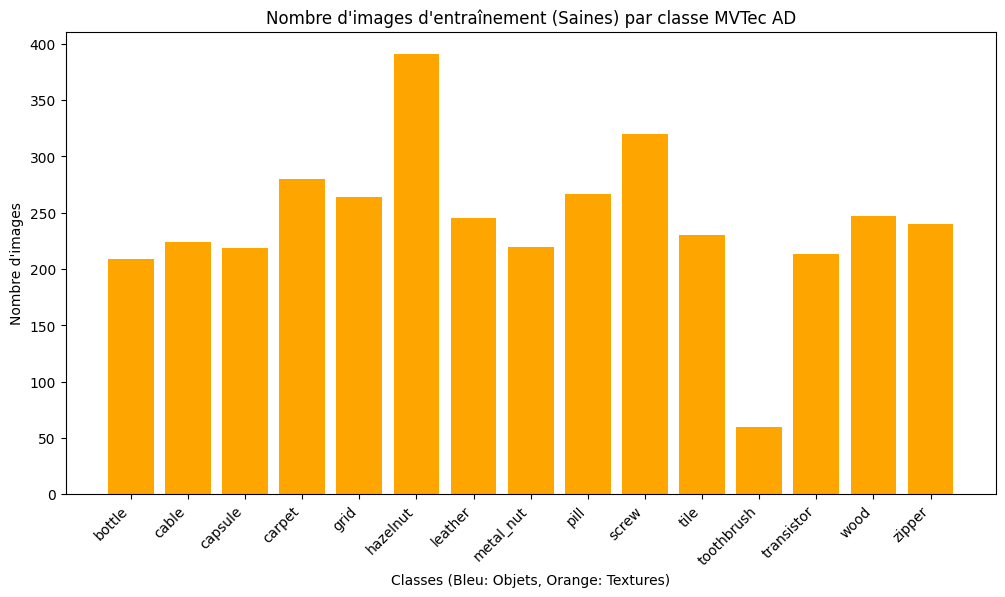

In [44]:
mvtec_train_counts = {
    "bottle": 209, "cable": 224, "capsule": 219, "hazelnut": 391,
    "metal_nut": 220, "pill": 267, "screw": 320, "toothbrush": 60,
    "transistor": 213, "zipper": 240, "carpet": 280, "grid": 264,
    "leather": 245, "tile": 230, "wood": 247
}
mvtec_train_counts = dict(sorted(mvtec_train_counts.items()))

categories = list(mvtec_train_counts.keys())
counts = list(mvtec_train_counts.values())

plt.figure(figsize=(12, 6))
bars = plt.bar(categories, counts,color="orange")
plt.xticks(rotation=45, ha='right')
plt.title("Nombre d'images d'entraînement (Saines) par classe MVTec AD")
plt.ylabel("Nombre d'images")
plt.xlabel("Classes (Bleu: Objets, Orange: Textures)")